# Visualizing data distributions

In [1]:
# Imports

library(dslabs)
library(tidyverse)

# Configuration

# Graphs are forced to be square by default and look too "smushed"
options(repr.plot.width = 10, repr.plot.height = 6)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   3.5.1     ✔ tibble    3.3.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


The long and short of this chapter is that it is often important to look beyond summary statistics such as mean and standard deviation and visualize things to get a better sense of patterns in data. As the famous late statistician John Tukey put it:

>The greatest value of a picture is when it forces us to notice what we never expected to see.

For the purposes of data visualization, it is important to have a good idea of how statistical distributions work, which leads us to...

## Variable types

At the highest level, data we will analyze will be *categorical* or *numerical*. In turn categorical variables can be divided into *ordinal* or not ordinal and numerical variables can be divided into *discrete* or *continuous*. Categorical data refer to groups rather than numbers as such. Examples include gender (male or female—**TRIGGERED**) and US regions (Northeast, South, North Central, West). There is no obvious order to these two categorical variables. On the other hand, when categorical variables have an obvious ordering, they are deemed *ordinal*, as with possible levels of spiciness in an order of chilaquiles:

![Mexican chilaquiles vendor uses pictures of Doge to illustrate the levels of spiciness](doge_chimlaquiles_levels.jpg)

Examples of numerical data population sizes, murder rates and heights. Continuous numerical data can be specified with more or less arbitrary granularity and therefore include the aforementioned murder rates and heights. For instance, a pair of twins may be 68.12 and 68.11 inches, respectively. Population size on the other hand is discrete because, at least since the end of the three-fifths compromise, it must be a round number.

However, things do get complicated, and I will crib directly from the book here:

>Keep in mind that discrete numeric data can be considered ordinal. Although this is technically true, we usually reserve the term ordinal data for variables belonging to a small number of different groups, with each group having many members. In contrast, when we have many groups with few cases in each group, we typically refer to them as discrete numerical variables. So, for example, the number of packs of cigarettes a person smokes a day, rounded to the closest pack, would be considered ordinal, while the actual number of cigarettes would be considered a numerical variable. But, indeed, there are examples that can be considered both numerical and ordinal when it comes to visualizing data.

The book will spend more time on visualizing numerical variables because it is more complex but will start with start with categorical variables.

## Case study: describing student heights

The book uses the somewhat circuitous example of giving a space alien and idea of how human height is distributed. Package dslabs contains `heights`, a data frame containing the heights in inches of 1050 (presumably adult) males and females. Sending our new alien pal the dataset is one way to inform them but doing so might end up in missing the forest for the trees. Understanding how statistical distributions work is key to providing a clearer picture of the data.

## Distributions

The book introduces statistical distributions as a sort of (my words not theirs) lossy compression of data that reflects on overall trends therein:

>For example, with categorical data, the distribution simply describes the proportion of each unique category. The sex represented in the heights dataset is:
>
>```
>#> 
>#> Female   Male 
>#>  0.227  0.773
>```
>This two-category *frequency table* is the simplest form of a distribution. We don’t really need to visualize it since one number describes everything we need to know: 23% are females and the rest are males.

By the way, the code to produce the above is more or less as follows:


In [2]:
heights |> select(sex) |> table() |> prop.table()

sex
   Female      Male 
0.2266667 0.7733333 

With three or more categories, it may be preferable to use a barplot. Here is a barplot where each bar represents what fraction of the 50 states *and* the District of Columbia each of the four regions of the United States takes up, as the book did it:

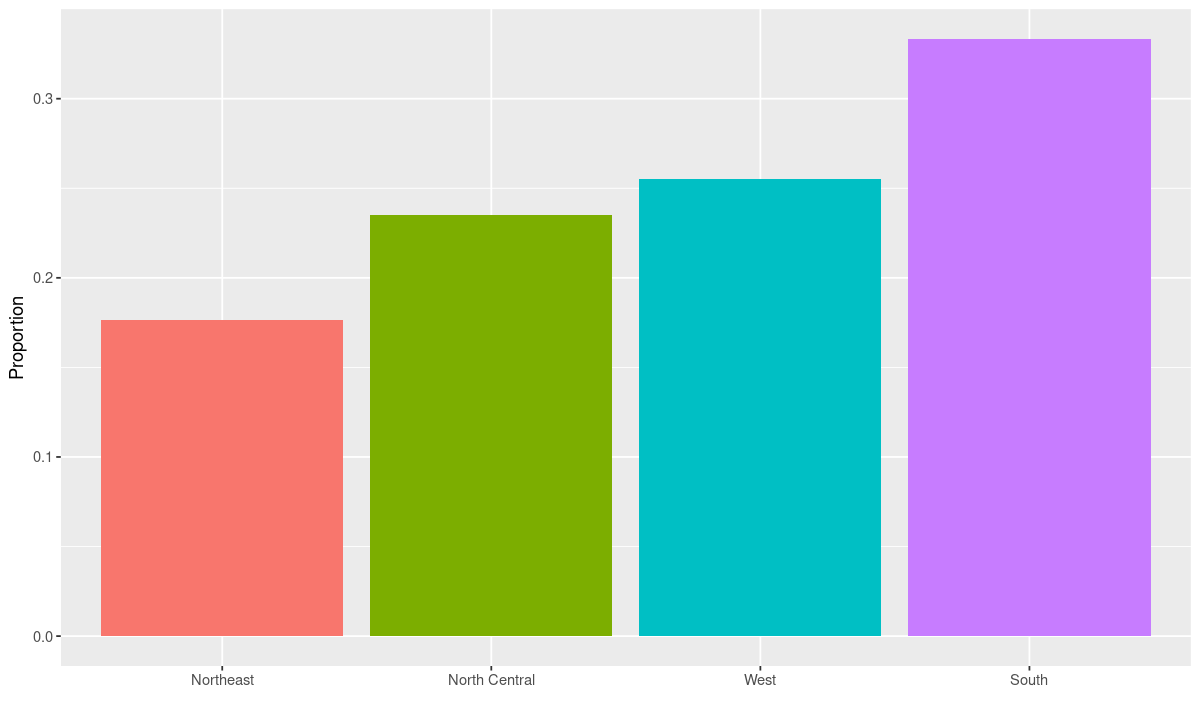

In [3]:
murders |> group_by(region) |>
    summarize(n = n()) |>
    mutate(Proportion = n/sum(n), region = reorder(region, Proportion)) |>
ggplot(aes(x=region, y=Proportion, fill=region)) + 
    geom_bar(stat = 'identity', show.legend = FALSE) + 
    xlab('')

Here's my slightly different way of going about things:

In [4]:
proportion_of_all_states <- murders |>
    group_by(region) |>
    summarize(n = n()) |>
    # Invocation of reorder() below is needed to make the colors match in the plot
    # It's just one of those areas where ggplot2 is a little opaque
    mutate(proportion = n / sum(n), region = reorder(region, proportion))
proportion_of_all_states

region,n,proportion
<fct>,<int>,<dbl>
Northeast,9,0.1764706
South,17,0.3333333
North Central,12,0.2352941
West,13,0.2549020


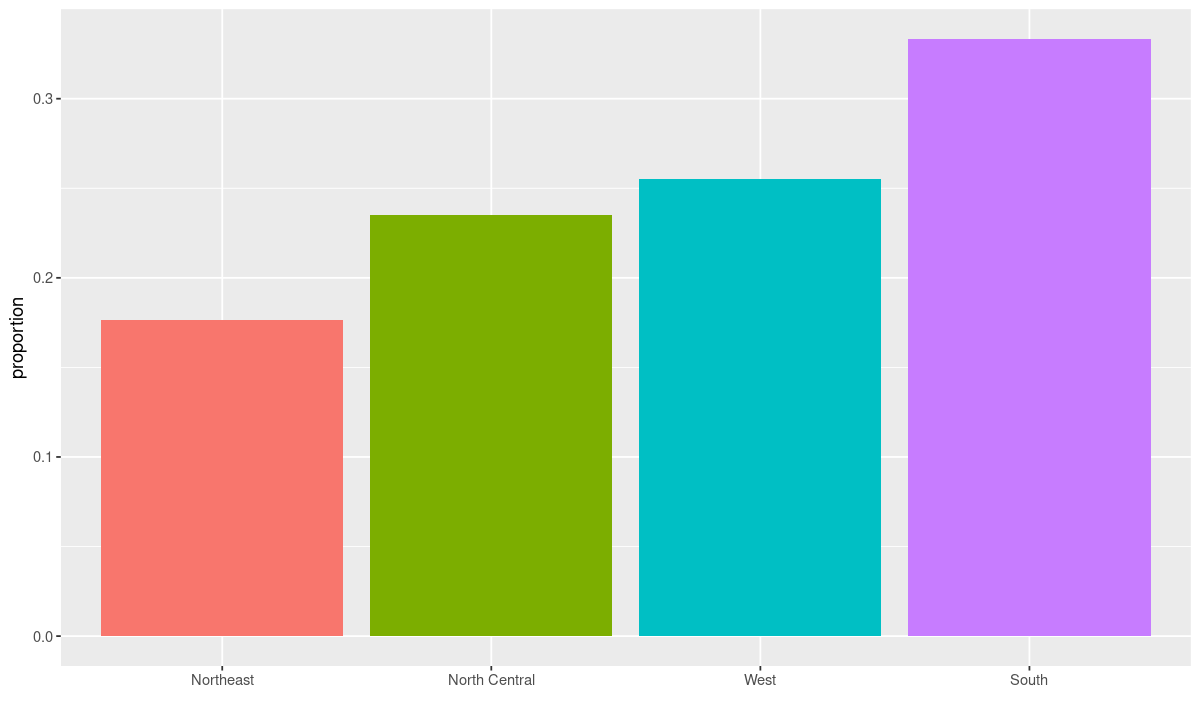

In [5]:
ggplot(proportion_of_all_states, aes(x = reorder(region, proportion), y = proportion, fill = region)) +
    geom_col(show.legend = FALSE) +
    xlab('')

>Although this particular plot does not provide much more insight than a frequency table itself, it is a first example of how we convert a vector into a plot that succinctly summarizes all the information in the vector. When the data is numerical, the task of displaying distributions is more challenging.

### Histograms

Genuinely numerical data require a different approach than barplots as above as since, at most, they can often only be summarized as a multitude of different categories and, at worst, each one of them may be completely unique, or at least nearly so:

>For example, in our case study, while several students reported a height of 68 inches, only one student reported a height of 68.503937007874 inches and only one student reported a height 68.8976377952756 inches. We assume that they converted from 174 and 175 centimeters, respectively.

One way to summarize numerical data is by creating a so-called *empirical cumulative distribution function* (or *eCDF*) where the $x$-axis represents the observed domain of values in a sample and each point on the $y$-axis represents what fraction of the data are less than or equal to the corresponding value on the $x$-axis. Here's how the book portrays the eCDF for the variable of adult male height:

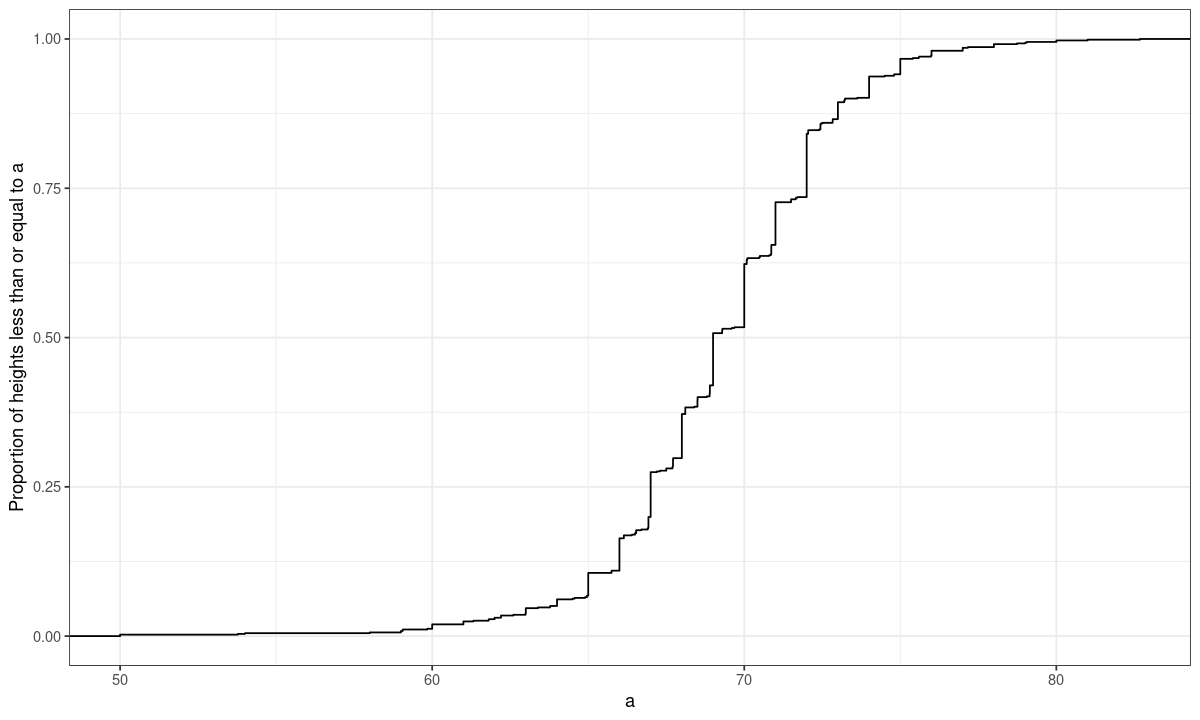

In [6]:
ds_theme_set()
heights |> filter(sex == 'Male') |>
    ggplot(aes(height)) +
    stat_ecdf() +
    ylab('Proportion of heights less than or equal to a') +
    xlab('a')

However, eCDFs are not very popular in practice. Why?

>The main reason is that it does not easily convey characteristics of interest such as: at what value is the distribution centered? Is the distribution symmetric? What ranges contain 95% of the values?

Instead we will now look at *histograms*, which are a bit lossy compared to the eCDF, but convey such information in the previous quote as one might expect far more effectively. Again, according to the book:

>The simplest way to make a histogram is to divide the span of our data into non-overlapping bins of the same size. Then, for each bin, we count the number of values that fall in that interval. The histogram plots these counts as bars with the base of the bar defined by the intervals. Here is the histogram for the height data splitting the range of values into one inch intervals: $(49.5, 50.5], (50.5, 51.5], (51.5, 52.5], (52.5, 52.3], \ldots, (82.5, 83.5]$

The book hasn't taught us to do this one yet either so I'll crib the code:

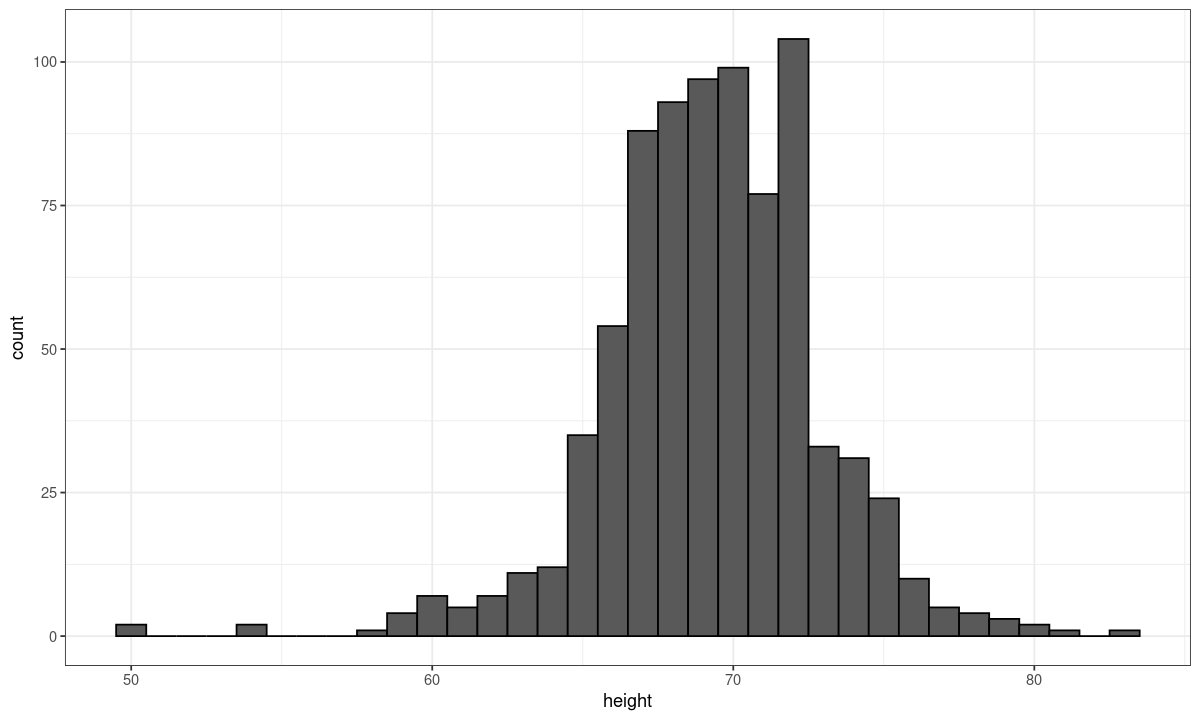

In [7]:
heights |> 
  filter(sex == 'Male') |> 
  ggplot(aes(height)) + 
  geom_histogram(binwidth = 1, color = 'black')

The histogram above is similar to a barplot but the $x$-axis is numerical rather than categorical. In order to give a decent overview of the data as a whole that is not too "chunky", the number of bins chosen is substantially larger than what would make sense for a barplot. Our new alien friend, upon seeing the histogram plot, will see the overall distribution of most the data, where there are outliers and that the data are largely symmetrical around the peak density of 69 inches (nice).

Remember what I said about histograms being "lossy"?

>What information do we lose? Note that all values in each interval are treated the same when computing bin heights. So, for example, the histogram does not distinguish between 64, 64.1, and 64.2 inches. Given that these differences are almost unnoticeable to the eye, the practical implications are negligible and we were able to summarize the data to just 23 numbers.

### Smoothed density

An alternative to histograms that perhaps a better "gist" of the data than even histograms themselves is a smoothed density plot. Because the book has not provided instructions on how to create them either, I will again go cribbing:

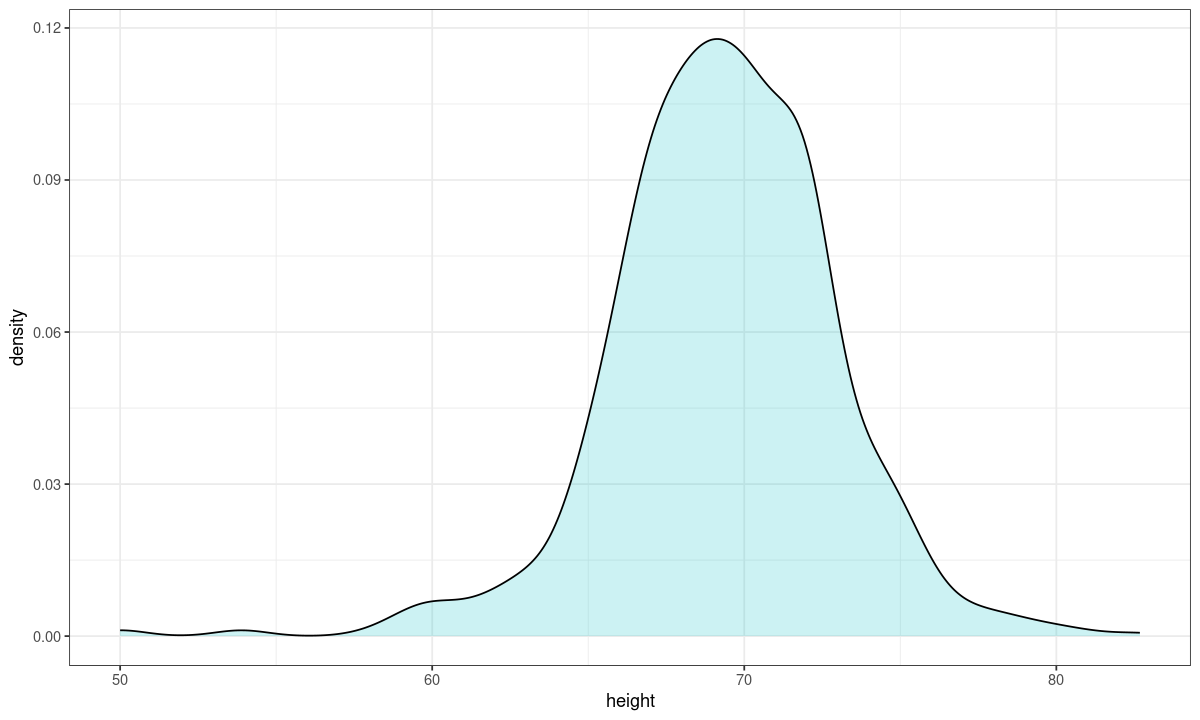

In [8]:
heights |> 
  filter(sex == 'Male') |> 
  ggplot(aes(height)) + 
  geom_density(alpha = .2, fill= '#00BFC4', color = 0) +
  geom_line(stat = 'density')

There are more advanced details that one is required to get into to understand fully what is going on here, but for now it's adequate to point out that the idea that the distribution has a sense of centrality with something resembling symmetry is more obvious here, and it's also worth mentioning that, instead of counts, the $y$-axis now shows density and that the area under the curve sums to 1. Therefore, the area of any interval with a lower- and/or upper-bound that is a fraction of the density curve will show what proportion of the data that interval encompasses.

Another advantage of smooth density plots is that, as there aren't a bunch of vertical lines taking up visual space like there would be with histograms, it's quite easy to use alpha compositing to compare two (or perhaps more) density plots. Here's an example of comparing the distribution of male and female heights in the `heights` dataset (and note that there is a larger variance with the males). Again I will crib:

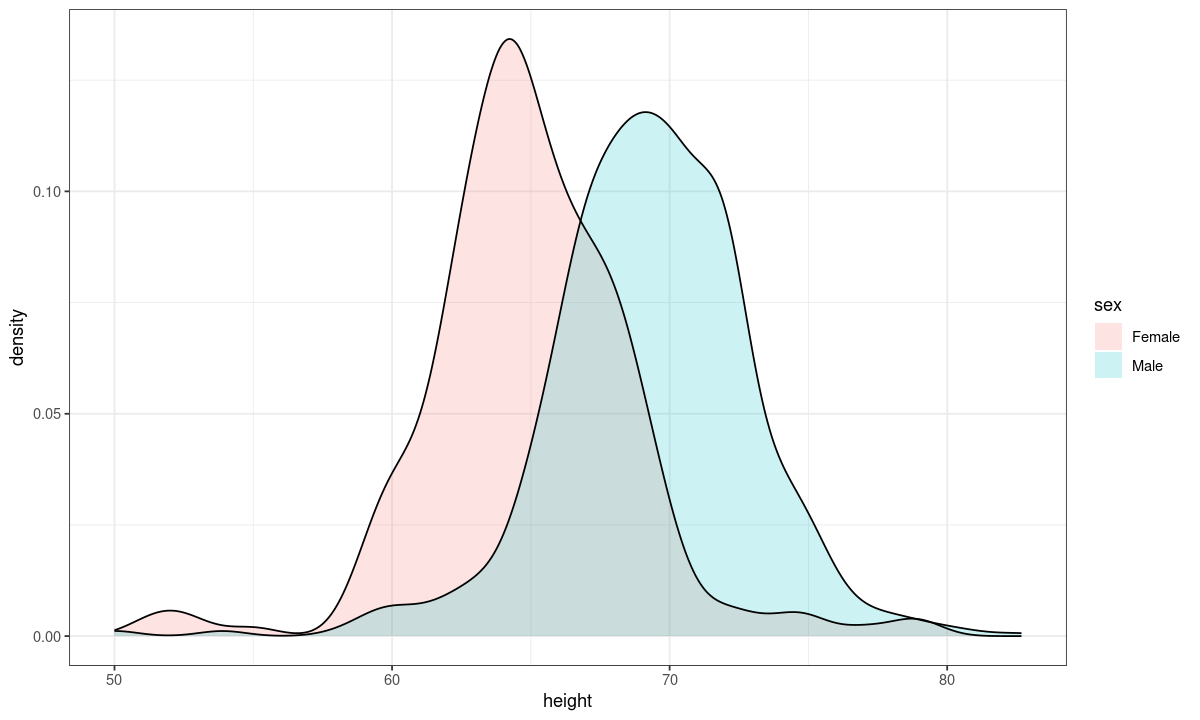

In [9]:
heights |> 
  ggplot(aes(height, fill=sex)) + 
  geom_density(alpha = 0.2, color = 0) +
  geom_line(stat='density')

### The normal distribution

Also known as the *bell curve* and the *Gaussian distrbution*, here's an approximation of the standard normal distribution using interpolation between 100 known points of its respective $x$- and $y$-coordinates:

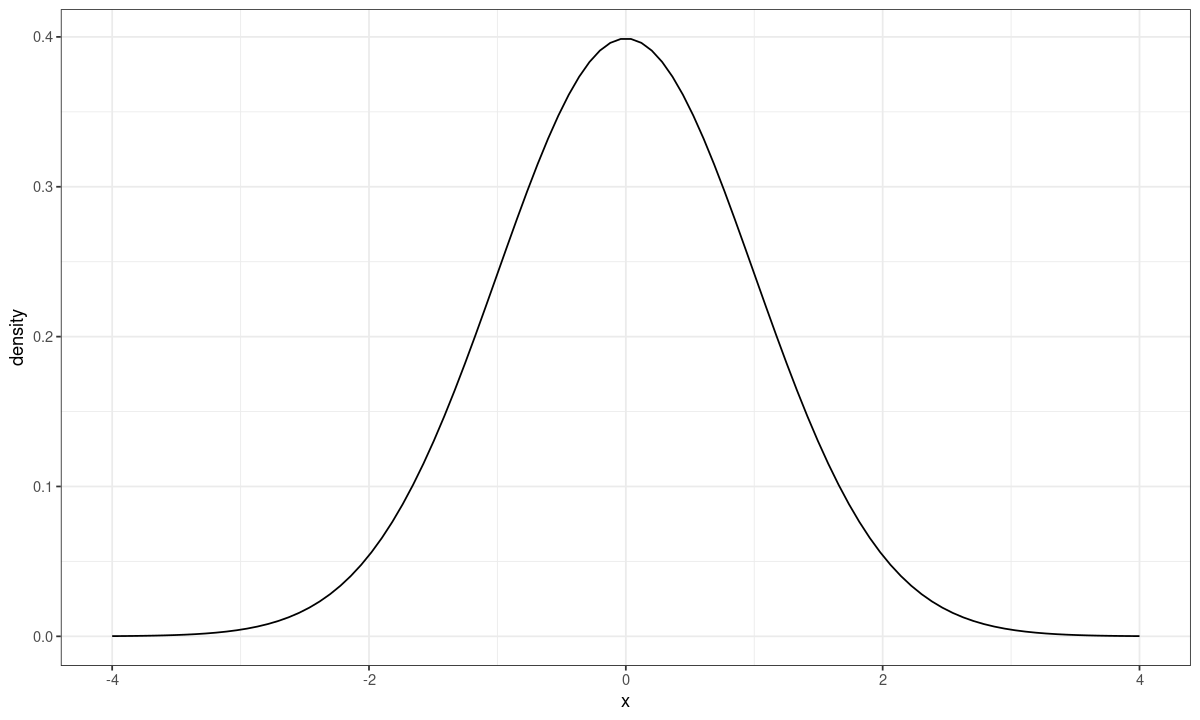

In [10]:
mu <- 0
s <- 1
norm_dist <- data.frame(x=seq(-4, 4, len = 100) * s + mu) |> mutate(density = dnorm(x, mu, s))
norm_dist |> ggplot(aes(x, density)) + geom_line()

The normal distribution is characterized by only two parameters, the mean and standard deviation, and can describe the distributions of many things, like "gambling winnings, heights, weights, blood pressure, standardized test scores, and experimental measurement error". Just be sure that when you are using it you are not like the proverbial carpenter who only has a hammer and sees everything as a nail! If you are convinced that the data you have in front of you come from a normal distribution (how to establish this will presumably be covered in [*Statistics and Prediction Algorithms Through Case Studies*](https://rafalab.dfci.harvard.edu/dsbook-part-2/), the sequel to this book), the parameters of the mean and standard deviation can be estimates as follows, here with the distribution of male heights, first the mean:

In [11]:
x <- heights |> filter(sex == 'Male') |> pull(height)
m <- sum(x) / length(x)
m

[1] 69.31475

And now the standard deviation (here with `length(x) - 1` in the denominator because it's the [sample standard deviation](https://www.reddit.com/r/learnmath/comments/lvxik0/why_do_we_divide_by_n1_and_not_n_when_calculating/)):

In [12]:
s <- sqrt(sum((x - m)^2) / (length(x) - 1))
s

[1] 3.611024

For future convenience instead of just pedagogic purposes, the built-in functions `mean()` and `sd()` can be used instead:

In [13]:
m <- mean(x)
s <- sd(x)
c(mean = m, sd = s)

mean        sd 
69.314755  3.611024

Because a lot still hasn't been explained, I will now commit a brazen act of wholesale theft and copy how the book compares the density plot of the observed data with the theoretical estimated normal distribution:

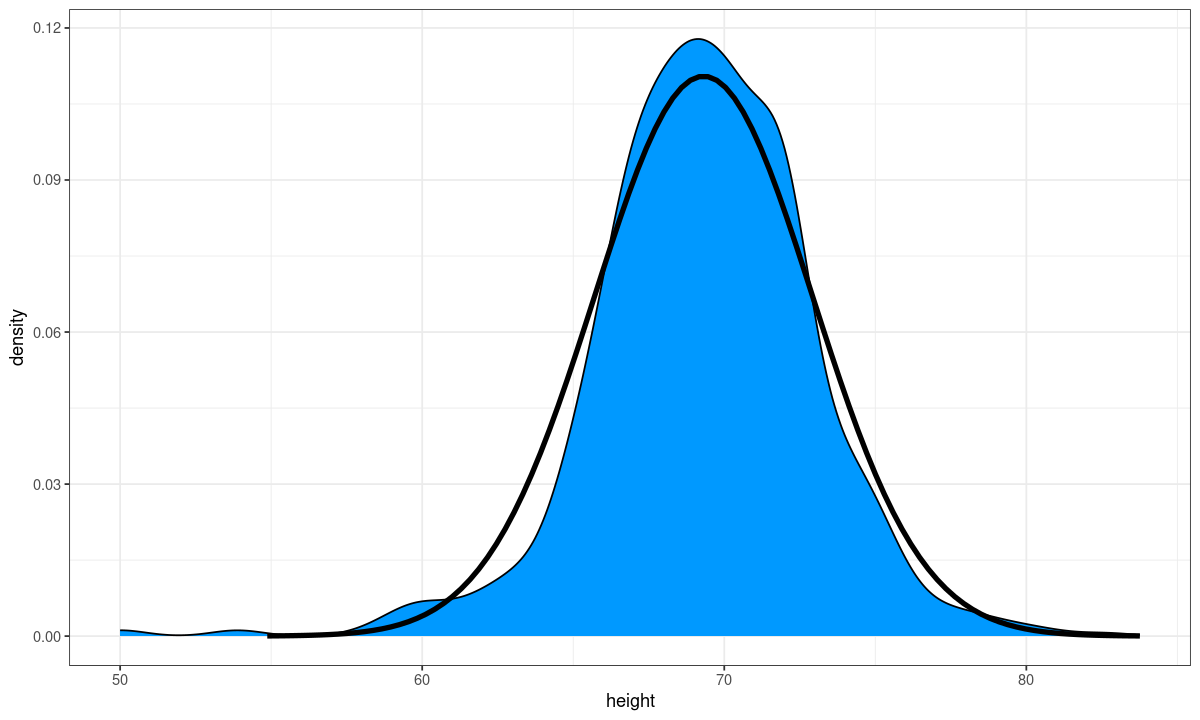

In [14]:
norm_dist <- data.frame(x = seq(-4, 4, len = 100) * s + m) |> 
  mutate(density = dnorm(x, m, s))

heights |> filter(sex == 'Male') |> ggplot(aes(height)) +
  geom_density(fill = '#0099FF') +
  geom_line(aes(x, density),  data = norm_dist, lwd = 1.5)